In [10]:
import os
import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import torch.nn.functional as F

Using device: cuda
Class mapping: {'fake': 0, 'real': 1}

Epoch [1/15]
Train Loss: 0.0668 | Train Acc: 0.9850
Val Loss:   0.0026 | Val Acc:   1.0000

Epoch [2/15]
Train Loss: 0.0022 | Train Acc: 0.9999
Val Loss:   0.0008 | Val Acc:   1.0000

Epoch [3/15]
Train Loss: 0.0010 | Train Acc: 0.9999
Val Loss:   0.0002 | Val Acc:   1.0000

Epoch [4/15]
Train Loss: 0.0003 | Train Acc: 1.0000
Val Loss:   0.0002 | Val Acc:   1.0000

Epoch [5/15]
Train Loss: 0.0003 | Train Acc: 1.0000
Val Loss:   0.0001 | Val Acc:   1.0000

Epoch [6/15]
Train Loss: 0.0010 | Train Acc: 0.9999
Val Loss:   0.0002 | Val Acc:   1.0000

Epoch [7/15]
Train Loss: 0.0001 | Train Acc: 1.0000
Val Loss:   0.0001 | Val Acc:   1.0000

Epoch [8/15]
Train Loss: 0.0002 | Train Acc: 1.0000
Val Loss:   0.0001 | Val Acc:   1.0000

Epoch [9/15]
Train Loss: 0.0002 | Train Acc: 1.0000
Val Loss:   0.0001 | Val Acc:   1.0000

Epoch [10/15]
Train Loss: 0.0002 | Train Acc: 1.0000
Val Loss:   0.0001 | Val Acc:   1.0000

Epoch [11/15]
Train L

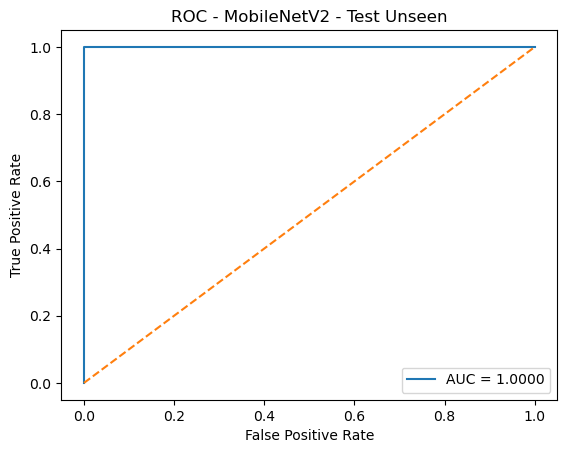

In [11]:


# ===============================
# 1️⃣ REPRODUCIBILITY
# ===============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ===============================
# 2️⃣ CONFIG
# ===============================
DATA_ROOT = r"D:\Datasets\Phase1_224x224_RGB"

MODEL_SAVE_PATH = r"D:\MinorProject\MinorProject6thSem\models\best_mobilenetv2_rgb_phase1.pth"

BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ===============================
# 3️⃣ TRANSFORMS
# ===============================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ===============================
# 4️⃣ DATASETS
# ===============================
train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"), transform=test_transform)
test_seen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_seen"), transform=test_transform)
test_unseen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_unseen"), transform=test_transform)

print("Class mapping:", train_dataset.class_to_idx)

# ===============================
# 5️⃣ DATALOADERS
# ===============================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_seen_loader = DataLoader(test_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_unseen_loader = DataLoader(test_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ===============================
# 6️⃣ MODEL (Modern API - No Warning)
# ===============================
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(DEVICE)

# ===============================
# 7️⃣ LOSS + OPTIMIZER + SCHEDULER
# ===============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# ===============================
# 8️⃣ EVALUATION FUNCTION (ROC READY)
# ===============================
def evaluate(model, loader, return_preds=False, return_probs=False):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probs = F.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if return_probs:
                all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    if return_preds and return_probs:
        return avg_loss, accuracy, all_preds, all_labels, all_probs

    if return_preds:
        return avg_loss, accuracy, all_preds, all_labels

    return avg_loss, accuracy

# ===============================
# 9️⃣ TRAINING LOOP
# ===============================
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    train_loss = running_loss / total
    train_acc = running_corrects / total
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

# ===============================
# 🔟 SAVE BEST MODEL
# ===============================
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print("\nBest model saved locally.")

# ===============================
# 1️⃣1️⃣ FINAL EVALUATION
# ===============================
train_loss, train_acc = evaluate(model, train_loader)
val_loss, val_acc = evaluate(model, val_loader)

test_seen_loss, test_seen_acc, seen_preds, seen_labels = evaluate(model, test_seen_loader, True)
test_unseen_loss, test_unseen_acc, unseen_preds, unseen_labels, unseen_probs = evaluate(
    model, test_unseen_loader, return_preds=True, return_probs=True
)

# ROC & AUC (Unseen)
fpr, tpr, thresholds = roc_curve(unseen_labels, unseen_probs)
roc_auc = auc(fpr, tpr)

print("\n===== FINAL RESULTS =====")
print(f"Train Acc:       {train_acc:.4f}")
print(f"Validation Acc:  {val_acc:.4f}")
print(f"Test Seen Acc:   {test_seen_acc:.4f}")
print(f"Test Unseen Acc: {test_unseen_acc:.4f}")
print(f"Test Unseen AUC: {roc_auc:.4f}")

print("\nConfusion Matrix - Test Seen")
print(confusion_matrix(seen_labels, seen_preds))
print(classification_report(seen_labels, seen_preds))

print("\nConfusion Matrix - Test Unseen")
print(confusion_matrix(unseen_labels, unseen_preds))
print(classification_report(unseen_labels, unseen_preds))

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - MobileNetV2 - Test Unseen")
plt.legend()
plt.show()

In [12]:
import os

train_fake = set(os.listdir(r"D:\Datasets\Phase1_224x224_RGB\train\fake"))
unseen_fake = set(os.listdir(r"D:\Datasets\Phase1_224x224_RGB\test_unseen\fake"))

intersection = train_fake.intersection(unseen_fake)
print("Overlap count:", len(intersection))

Overlap count: 0


In [13]:
print(min(unseen_probs), max(unseen_probs))
print("Lowest 20 probs:", sorted(unseen_probs)[:20])
print("Highest 20 probs:", sorted(unseen_probs)[-20:])

0.0003332073 0.9999696
Lowest 20 probs: [np.float32(0.0003332073), np.float32(0.00033734136), np.float32(0.00033906236), np.float32(0.0004003419), np.float32(0.0005033852), np.float32(0.0007293115), np.float32(0.0007763197), np.float32(0.00078461965), np.float32(0.00079037616), np.float32(0.0008045515), np.float32(0.0008643083), np.float32(0.00089889596), np.float32(0.0009159602), np.float32(0.0009641512), np.float32(0.0009997134), np.float32(0.0010090903), np.float32(0.0010877154), np.float32(0.0011857501), np.float32(0.0012634746), np.float32(0.0013997696)]
Highest 20 probs: [np.float32(0.9998578), np.float32(0.9998578), np.float32(0.9998616), np.float32(0.9998672), np.float32(0.99987423), np.float32(0.999876), np.float32(0.99988353), np.float32(0.99988616), np.float32(0.99988735), np.float32(0.9998944), np.float32(0.9999013), np.float32(0.99990475), np.float32(0.99991167), np.float32(0.99991643), np.float32(0.9999168), np.float32(0.99993014), np.float32(0.9999323), np.float32(0.9999